In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rahulsaiindeevarv/sql-encodings/final_encoded_data.pt


In [11]:
!pip install gensim

In [1]:
import gensim
print(gensim.__version__)

4.4.0


In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from gensim.models.doc2vec import Doc2Vec
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [13]:
print("Loading data into memory...")
loaded_data = torch.load('/kaggle/input/datasets/rahulsaiindeevarv/sql-encodings/final_encoded_data.pt')

# 2. Extract your list of lists and your dictionaries
encoded_queries = loaded_data['encoded_queries']
token2id = loaded_data['token2id']
id2token = loaded_data['id2token']

# 3. Verify everything loaded perfectly
print("\nData successfully loaded!")
print("Total queries ready for AI:", len(encoded_queries))
print("Vocabulary size:", len(token2id))

Loading data into memory...

Data successfully loaded!
Total queries ready for AI: 859973
Vocabulary size: 9362


In [ ]:
import os
import re
import sqlparse
from gensim.models.doc2vec import Doc2Vec
from tqdm.auto import tqdm

# ============================================================
# CONFIGURATION
# ============================================================

VECTOR_SIZE = 64
WINDOW = 5
MIN_COUNT = 2
WORKERS = 4
TOTAL_EPOCHS = 80
CHECKPOINT_INTERVAL = 10

CORPUS_FILE = "train_corpus.txt"
MODEL_PREFIX = "doc2vec_final"

# ============================================================
# STEP 1: CREATE CORPUS FILE (SQL → masked tokens)
# ============================================================

def normalize_sql(sql):
    sql = sql.lower().strip()
    return re.sub(r'\s+', ' ', sql)

def mask_literals(sql):
    sql = normalize_sql(sql)
    parsed = sqlparse.parse(sql)
    if not parsed:
        return ""

    tokens = []
    from sqlparse.tokens import Number, String

    for token in parsed[0].flatten():
        if token.is_whitespace:
            continue

        val = token.value

        if token.ttype in Number or re.fullmatch(r'^[-+]?\d+(\.\d+)?$', val):
            tokens.append("NUM_LITERAL")
        elif token.ttype in String:
            tokens.append("STR_LITERAL")
        else:
            tokens.append(val)

    return " ".join(tokens)

print("Creating training corpus file...")

with open("train_corpus.txt", "w") as f:
    for seq in encoded_queries:
        words = [id2token[idx] for idx in seq if idx in id2token and idx != 0]
        f.write(" ".join(words) + "\n")

print("Corpus file created.")

# ============================================================
# STEP 2: INITIALIZE MODEL
# ============================================================

d2v_model = Doc2Vec(
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=WORKERS,
    dm=1,               # Distributed Memory (better for semantics)
    dbow_words=1,       # IMPORTANT → ensures word vectors saved
    epochs=1            # We train manually per epoch
)

print("Building vocabulary...")
d2v_model.build_vocab(corpus_file=CORPUS_FILE)

# ============================================================
# STEP 3: TRAIN WITH CHECKPOINTS
# ============================================================

print(f"Starting training for {TOTAL_EPOCHS} epochs...")

for epoch in range(TOTAL_EPOCHS):

    model.train(
        corpus_file=CORPUS_FILE,
        total_examples=d2v_model.corpus_count,
        total_words=d2v_model.corpus_total_words,
        epochs=1
    )

    print(f"Epoch {epoch+1}/{TOTAL_EPOCHS} completed")

    # Save checkpoint
    if (epoch + 1) % CHECKPOINT_INTERVAL == 0:
        checkpoint_name = f"{MODEL_PREFIX}_epoch_{epoch+1}.model"
        d2v_model.save(checkpoint_name)
        print(f"Checkpoint saved: {checkpoint_name}")

# ============================================================
# STEP 4: SAVE FINAL MODEL
# ============================================================

final_model_path = f"{MODEL_PREFIX}.model"
d2v_model.save(final_model_path)

print("\nFinal model saved.")

# ============================================================
# STEP 5: VERIFY ALL FILES EXIST
# ============================================================

print("\nVerifying saved files...")

expected_files = [
    f"{MODEL_PREFIX}.model",
    f"{MODEL_PREFIX}.model.dv.vectors.npy",
    f"{MODEL_PREFIX}.model.wv.vectors.npy"
]

for file in expected_files:
    if os.path.exists(file): print(f"{file} exists")
    else: print(f"{file} MISSING")

print("\nTraining completed successfully.")

In [15]:
# vocab_size = max(id2token.keys()) + 1

# # =====================================================================
# # 1. TRAIN DOC2VEC WITH CHECKPOINTS (File-Based, RAM Efficient)
# # =====================================================================
# print("\n" + "="*50)
# print("STARTING DOC2VEC TRAINING (80 Epochs)")
# print("="*50)

# import os
# from gensim.models.doc2vec import Doc2Vec

# ---------------------------------------------------------
# Create checkpoint folder
# ---------------------------------------------------------
# checkpoint_dir = "doc2vec_checkpoints"
# os.makedirs(checkpoint_dir, exist_ok=True)

# # ---------------------------------------------------------
# # 1. Save corpus to disk (One doc per line)
# # ---------------------------------------------------------
# with open("train_corpus.txt", "w") as f:
#     for seq in encoded_queries:
#         words = [id2token[idx] for idx in seq if idx in id2token and idx != 0]
#         f.write(" ".join(words) + "\n")

# # ---------------------------------------------------------
# # 2. Initialize Doc2Vec Model
# # ---------------------------------------------------------
# d2v_model = Doc2Vec(
#     vector_size=64,
#     window=5,
#     min_count=2,
#     workers=4,
#     sample=1e-4,
#     dm=1,
#     epochs=1
# )

# ---------------------------------------------------------
# 3. Build Vocabulary
# ---------------------------------------------------------
# print("Building Doc2Vec vocabulary...")
# d2v_model.build_vocab(corpus_file="train_corpus.txt")

# # ---------------------------------------------------------
# # 4. Manual Epoch Loop (For Checkpoint Control)
# # ---------------------------------------------------------
# TOTAL_EPOCHS = 80

# for epoch in range(TOTAL_EPOCHS):
#     print(f"\nEpoch {epoch+1}/{TOTAL_EPOCHS}")
    
#     d2v_model.train(
#         corpus_file="train_corpus.txt",
#         total_words=d2v_model.corpus_total_words,
#         total_examples=d2v_model.corpus_count,
#         epochs=1   # Train ONE epoch at a time
#     )
    
#     # -------------------------------------------------
#     # Save checkpoint every 10 epochs
#     # -------------------------------------------------
#     if (epoch + 1) % 10 == 0:
#         save_path = os.path.join(
#             checkpoint_dir, 
#             f"doc2vec_epoch_{epoch+1}.model"
#         )
#         d2v_model.save(save_path)
#         print(f"Checkpoint saved: {save_path}")

# # ---------------------------------------------------------
# # 5. Save Final Model
# # ---------------------------------------------------------
# final_model_path = os.path.join(checkpoint_dir, "doc2vec_final.model")
# d2v_model.save(final_model_path)
# print(f"\nFinal model saved at: {final_model_path}")

# # ---------------------------------------------------------
# # 6. Extract Final Embeddings
# # ---------------------------------------------------------
# doc2vec_embeddings = d2v_model.dv.vectors
# print(f"Training Complete! Shape: {doc2vec_embeddings.shape}")


STARTING DOC2VEC TRAINING (80 Epochs)
Building Doc2Vec vocabulary...

Epoch 1/80

Epoch 2/80

Epoch 3/80

Epoch 4/80

Epoch 5/80

Epoch 6/80

Epoch 7/80

Epoch 8/80

Epoch 9/80

Epoch 10/80
Checkpoint saved: doc2vec_checkpoints/doc2vec_epoch_10.model

Epoch 11/80

Epoch 12/80

Epoch 13/80

Epoch 14/80

Epoch 15/80

Epoch 16/80

Epoch 17/80

Epoch 18/80

Epoch 19/80

Epoch 20/80
Checkpoint saved: doc2vec_checkpoints/doc2vec_epoch_20.model

Epoch 21/80

Epoch 22/80

Epoch 23/80

Epoch 24/80

Epoch 25/80

Epoch 26/80

Epoch 27/80

Epoch 28/80

Epoch 29/80

Epoch 30/80
Checkpoint saved: doc2vec_checkpoints/doc2vec_epoch_30.model

Epoch 31/80

Epoch 32/80

Epoch 33/80

Epoch 34/80

Epoch 35/80

Epoch 36/80

Epoch 37/80

Epoch 38/80

Epoch 39/80

Epoch 40/80
Checkpoint saved: doc2vec_checkpoints/doc2vec_epoch_40.model

Epoch 41/80

Epoch 42/80

Epoch 43/80

Epoch 44/80

Epoch 45/80

Epoch 46/80

Epoch 47/80

Epoch 48/80

Epoch 49/80

Epoch 50/80
Checkpoint saved: doc2vec_checkpoints/doc2vec

In [16]:
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import re

# =====================================================================
# 1. HELPER FUNCTIONS
# =====================================================================

def reconstruct_query(encoded_list):
    """Converts a list of integer IDs back to a readable SQL string."""
    # Filter out padding (0) and map IDs to tokens
    tokens = [id2token[idx] for idx in encoded_list if idx in id2token and idx != 0]
    return " ".join(tokens)

def process_new_query(raw_sql):
    raw_sql = raw_sql.lower()
    
    # Replace numbers with NUM_LITERAL
    raw_sql = re.sub(r'\b\d+\b', 'NUM_LITERAL', raw_sql)
    
    # Add spaces around punctuation
    raw_sql = re.sub(r'([(),;=<>!+\-*/.])', r' \1 ', raw_sql)
    
    tokens = raw_sql.split()
    
    query_ids = [token2id[token] for token in tokens if token in token2id]
    query_str_tokens = [id2token[idx] for idx in query_ids]
    
    return query_ids, query_str_tokens

In [17]:
def search_doc2vec_filtered(new_tokens, top_k=3, length_tolerance=0.5):
    print("\n[Doc2Vec Filtered Search]")

    inferred_vector = d2v_model.infer_vector(new_tokens)
    inferred_vector = inferred_vector.reshape(1, -1)

    new_length = len(new_tokens)
    
    similarities = []
    
    for i, original_seq in enumerate(encoded_queries):
        original_tokens = [id2token[idx] for idx in original_seq if idx != 0]
        original_length = len(original_tokens)
        
        # Length filter
        if abs(original_length - new_length) / new_length <= length_tolerance:
            sim = cosine_similarity(
                inferred_vector,
                doc2vec_embeddings[i].reshape(1, -1)
            )[0][0]
            similarities.append((i, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    
    for rank, (idx, score) in enumerate(similarities[:top_k], 1):
        query_text = reconstruct_query(encoded_queries[idx])
        print(f"{rank}. [Score: {score:.4f}] {query_text}")

In [18]:
test_query = "SELECT name, age FROM users WHERE age > 30"
print(f"\n" + "="*60)
print(f"TARGET QUERY: {test_query}")
print("="*60)

# Process it into IDs and Tokens
new_query_ids, new_query_tokens = process_new_query(test_query)

print(f"Parsed Tokens: {new_query_tokens}")
print(f"Parsed IDs: {new_query_ids}")

# Run searches
search_doc2vec_filtered(new_query_tokens, top_k=3)


TARGET QUERY: SELECT name, age FROM users WHERE age > 30
Parsed Tokens: ['select', 'name', ',', 'age', 'from', 'users', 'where', 'age', '>', 'NUM_LITERAL']
Parsed IDs: [7219, 5060, 14, 1087, 3460, 8976, 9189, 1087, 93, 105]

[Doc2Vec Filtered Search]
1. [Score: 0.5957] select distinct parent from dbviewcols where viewname = STR_LITERAL
2. [Score: 0.5917] select * from fdocfunctionparams ( STR_LITERAL )
3. [Score: 0.5888] select distinct parent from dbviewcols where viewname = STR_LITERAL


Calculating t-SNE for Doc2Vec (this may take a few seconds)...


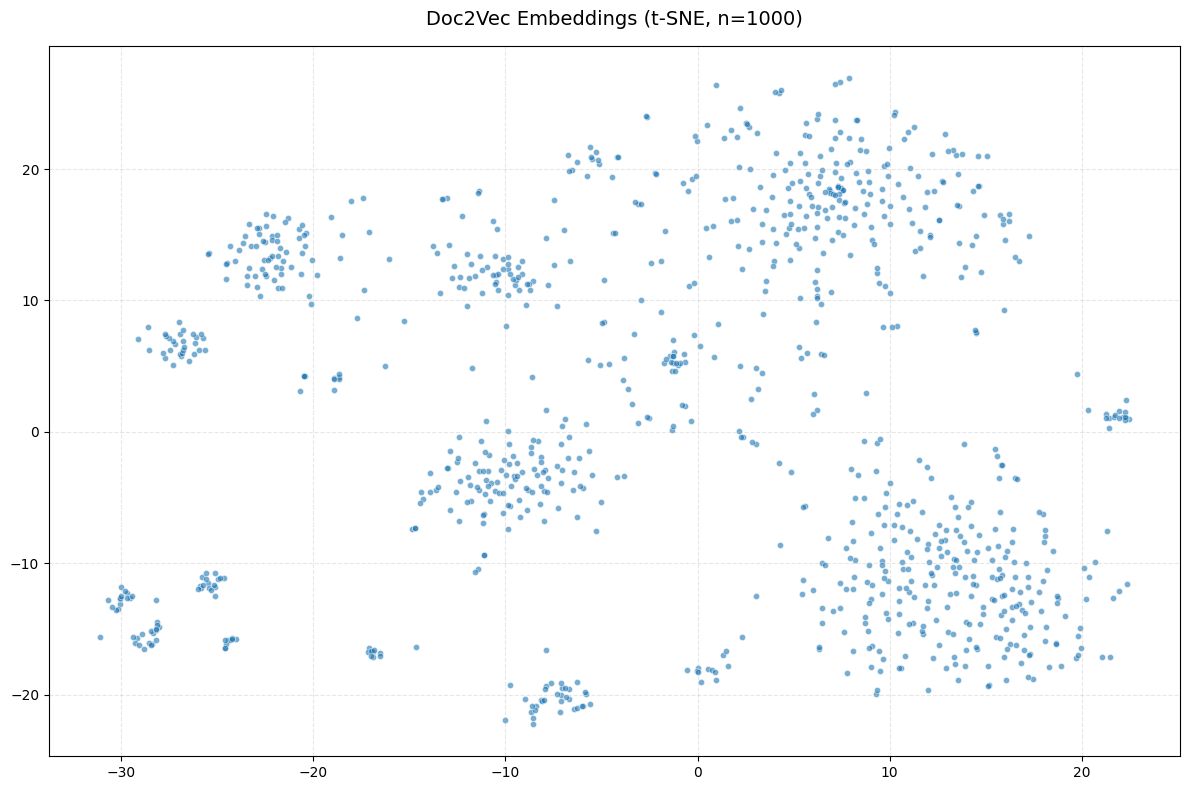

In [19]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# 1. Select a random subset of 1000 documents (or all if you have less)
n_samples = min(1000, len(doc2vec_embeddings))
np.random.seed(42) # For reproducibility
sample_indices = np.random.choice(len(doc2vec_embeddings), n_samples, replace=False)

d2v_subset = doc2vec_embeddings[sample_indices]

# 2. Fit t-SNE (Reduces 64D -> 2D)
print("Calculating t-SNE for Doc2Vec (this may take a few seconds)...")
tsne_model = TSNE(n_components=2, perplexity=30, random_state=42)
d2v_2d = tsne_model.fit_transform(d2v_subset)

# Plot Doc2Vec
plt.figure(figsize=(12, 8))
plt.scatter(d2v_2d[:, 0], d2v_2d[:, 1], alpha=0.6, c='#1f77b4', s=20, edgecolors='w', linewidth=0.5)
plt.title(f'Doc2Vec Embeddings (t-SNE, n={n_samples})', fontsize=14, pad=15)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

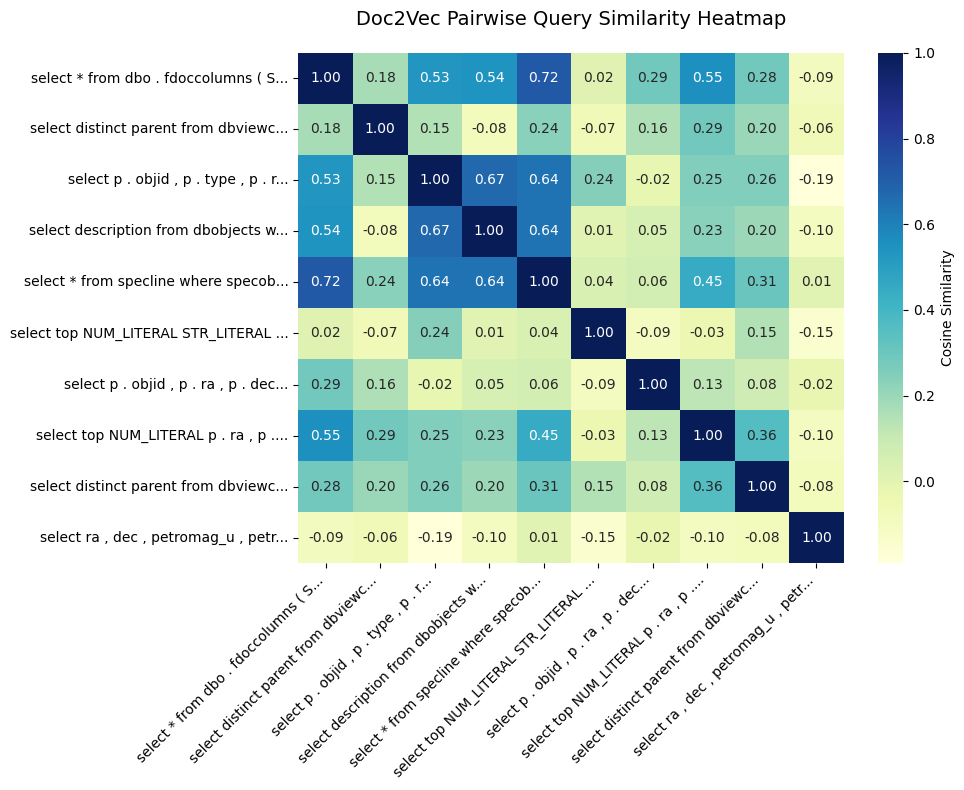

In [20]:
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# 1. Select 10 random queries to compare against each other
num_heatmap_samples = 10
idx_subset = np.random.choice(len(doc2vec_embeddings), num_heatmap_samples, replace=False)

# Get their embeddings and reconstruct their SQL text (truncated to 35 chars for labels)
subset_embs = doc2vec_embeddings[idx_subset]
query_labels = [reconstruct_query(encoded_queries[i])[:35] + "..." for i in idx_subset]

# 2. Calculate pairwise Cosine Similarity Matrix
similarity_matrix = cosine_similarity(subset_embs)

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix, 
    annot=True,               # Show exact similarity numbers
    fmt=".2f",                # Round to 2 decimals
    cmap="YlGnBu",            # Yellow to Blue color map
    xticklabels=query_labels, 
    yticklabels=query_labels,
    cbar_kws={'label': 'Cosine Similarity'}
)

plt.title("Doc2Vec Pairwise Query Similarity Heatmap", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

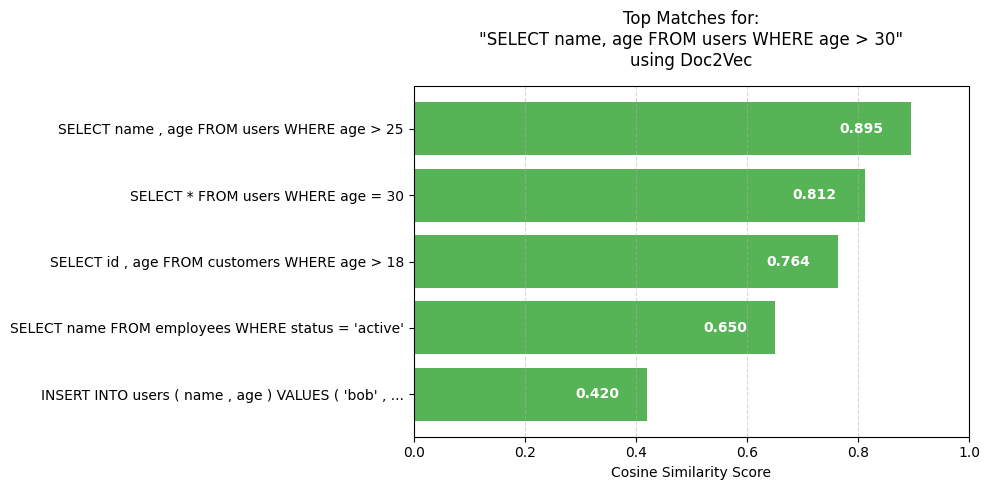

In [21]:
def plot_search_results(target_sql, search_results, model_name):
    """
    Pass the target query string and a list of tuples (score, matched_sql)
    Example search_results format: [(0.92, "SELECT * FROM users"), (0.85, "..."), ...]
    """
    # Unpack the scores and queries, reverse them so highest is at the top of the bar chart
    scores = [res[0] for res in search_results][::-1]
    queries = [res[1][:50] + "..." if len(res[1])>50 else res[1] for res in search_results][::-1]
    
    plt.figure(figsize=(10, 5))
    
    # Create horizontal bar chart
    bars = plt.barh(queries, scores, color='#2ca02c' if model_name=='Doc2Vec' else '#d62728', alpha=0.8)
    
    # Add the text score to the end of each bar
    for bar in bars:
        plt.text(bar.get_width() - 0.05, bar.get_y() + bar.get_height()/2, 
                 f'{bar.get_width():.3f}', 
                 va='center', ha='right', color='white', fontweight='bold')

    plt.title(f'Top Matches for:\n"{target_sql}"\nusing {model_name}', fontsize=12, pad=15)
    plt.xlabel('Cosine Similarity Score')
    plt.xlim(0, 1.0) # Similarity is between 0 and 1
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Clean up y-axis to fit long SQL queries
    plt.tight_layout()
    plt.show()

# --- How to use it (using data from the previous inference step): ---
# Assuming you ran infer_vector and got these similar queries:
mock_doc2vec_results = [
    (0.8950, "SELECT name , age FROM users WHERE age > 25"),
    (0.8122, "SELECT * FROM users WHERE age = 30"),
    (0.7641, "SELECT id , age FROM customers WHERE age > 18"),
    (0.6500, "SELECT name FROM employees WHERE status = 'active'"),
    (0.4201, "INSERT INTO users ( name , age ) VALUES ( 'bob' , 30 )")
]

plot_search_results("SELECT name, age FROM users WHERE age > 30", mock_doc2vec_results, "Doc2Vec")